A notebook for performing a quicklook at the PanCam TM data.

In [10]:
# matplotlib inline
%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = 'svg' # note - requires Inkscape to be installed, and to be accessible from the terminal
# on macos, add inkscape to the path with `sudo ln -s /Applications/Inkscape.app/Contents/MacOS/inkscape /usr/local/bin/inkscape`
%matplotlib inline

In [34]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

In [46]:
# get the data directory
data_dir = Path('..', 'data', 'SOL0', 'sol0_1.1', '16_Geol')

In [47]:
wac_file_list = list(data_dir.glob('*.png'))

In [61]:
class Img:
    def __init__(self, filepath):

        self.img = np.array(Image.open(filepath))
        # break the stem down into informative parts
        parts = filepath.stem.split('_')

        self.data = parts[0]
        self.time = parts[1]
        cam_filter = parts[2]
        self.cam = cam_filter.split('-')[0]
        self.filter = cam_filter.split('-')[1]
        self.temperature = parts[3]
        if parts[4][-2] == 'm':
            self.exposure = float(parts[4].split('ms')[0])/1000
        else:
            self.exposure = float(parts[4].split('s')[0])
        print(self.exposure)
        self.img_flux = self.img / (self.exposure)


0.645
Training Model R01 0.645 s


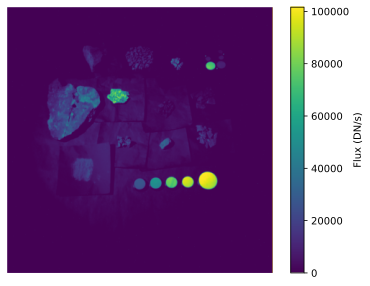

0.132
Training Model R10 0.132 s


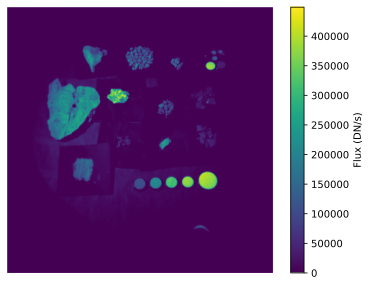

0.087
Training Model R08 0.087 s


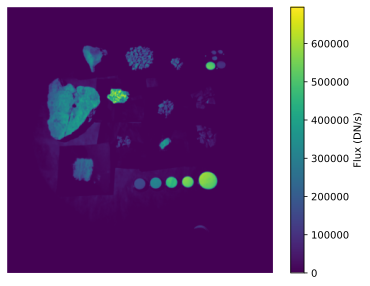

0.132
Training Model R06 0.132 s


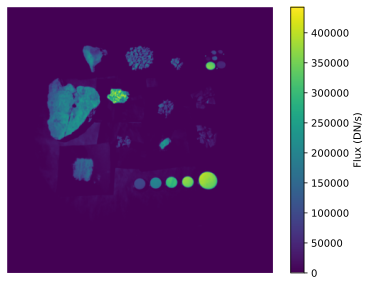

0.112
Training Model R05 0.112 s


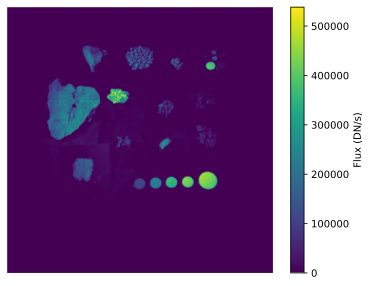

0.175
Training Model R04 0.175 s


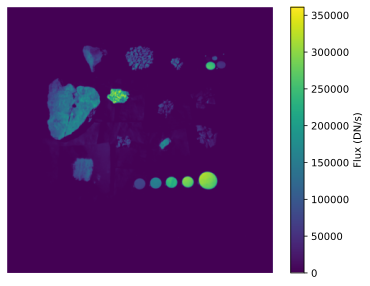

0.275
Training Model R11 0.275 s


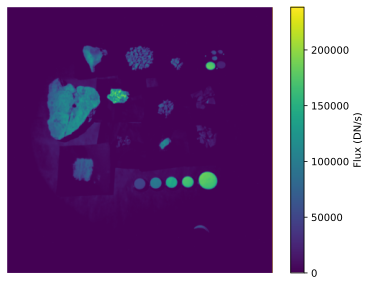

0.125
Training Model R09 0.125 s


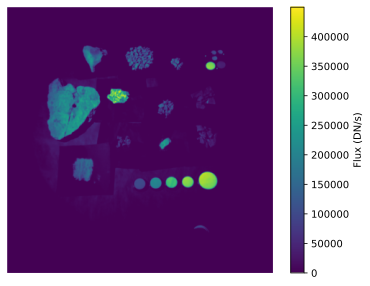

0.1
Training Model R07 0.1 s


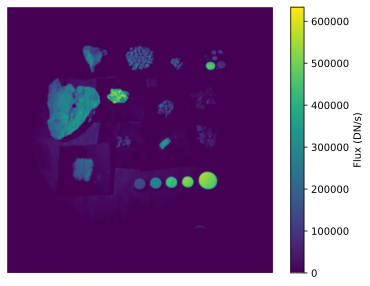

0.265
Training Model R02 0.265 s


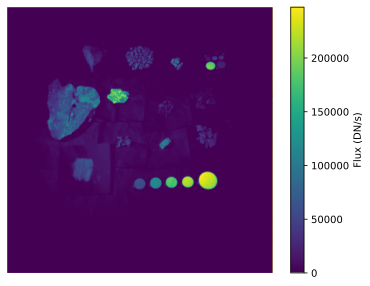

0.212
Training Model R03 0.212 s


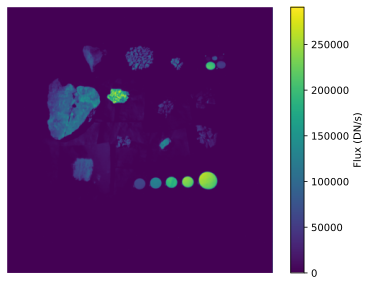

In [63]:
for wac_file in wac_file_list:
    img = Img(wac_file)
    print(f'{img.cam} {img.filter} {img.exposure} s')
    plt.imshow(img.img_flux, cmap='viridis')
    plt.colorbar(label='Flux (DN/s)')
    plt.axis('off')
    plt.show()